# Which states compress, and which do not

**FYS4480/FYS9480 — week 40.** Two states of the same $2^{L}$-dimensional space:

1. a **random** normalised vector,
2. the **ground state** of the transverse-field Ising chain, $\hat H=-\sum_i Z_iZ_{i+1}+g\sum_i X_i$.

Same size, same Hilbert space. We look at the Schmidt values at the middle bond, then at the overlap
and the energy as functions of the bond dimension $\chi$.

*Everything is driven by `run(...)` — change a parameter and re-run that one cell.*

In [107]:
import numpy as np, scipy.sparse as sp, scipy.sparse.linalg as spl
import matplotlib.pyplot as plt

# ----------------------------------------------------------------- parameters
L    = 12          # number of sites   (12 -> 4096 states, instant; 14 is still fine)
g    = 1.0         # transverse field  (1 = critical, <1 ordered, >1 paramagnetic)
seed = 0           # for the random state
CHIS = [1, 2, 4, 8, 16, 32, 64]

# colours of the lecture slides: pink, orange, purple
PINK, ORANGE, PURPLE = '#EB46BD', '#FF6300', '#8331E5'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[PINK, ORANGE, PURPLE])
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
# -----------------------------------------------------------------------------
d = 2

In [108]:
def ising_H(L, g):
    X = sp.csr_matrix([[0., 1.], [1., 0.]]); Z = sp.csr_matrix(np.diag([1., -1.])); I = sp.identity(2, format='csr')
    def op(o, i):
        M = sp.identity(1, format='csr')
        for k in range(L):
            M = sp.kron(M, o if k == i else I, format='csr')
        return M
    H = sp.csr_matrix((2**L, 2**L))
    for i in range(L - 1): H = H - op(Z, i) @ op(Z, i + 1)
    for i in range(L):     H = H + g * op(X, i)
    return H

def weights(v, L, b=None):                       # Schmidt weights at the middle bond
    b = L // 2 if b is None else b
    s = np.linalg.svd(v.reshape(2**b, 2**(L - b)), compute_uv=False)
    return s**2 / np.sum(s**2)

def entropy(w):
    w = w[w > 1e-16];  return float(-np.sum(w * np.log(w)))

def truncate(v, L, chi):                         # MPS of bond dimension <= chi, contracted back
    ts, R, chi_l = [], v.reshape(1, -1), 1
    for i in range(L - 1):
        U, S, Vh = np.linalg.svd(R.reshape(chi_l * d, -1), full_matrices=False)
        k = min(chi, int(np.sum(S > 1e-14)))
        ts.append(U[:, :k].reshape(chi_l, d, k))
        R = np.diag(S[:k]) @ Vh[:k];  chi_l = k
    ts.append(R.reshape(chi_l, d, 1))
    out = ts[0]
    for T in ts[1:]:
        out = np.tensordot(out, T, axes=([-1], [0]))
    out = out.reshape(-1)
    return out / np.linalg.norm(out)

def run(L=L, g=g, seed=seed, chis=None, plot=True):
    chis = [c for c in (chis or CHIS) if c <= 2**(L // 2)]
    H = ising_H(L, g)
    w, V = spl.eigsh(H, k=1, which='SA')
    psi = V[:, 0] / np.linalg.norm(V[:, 0]);  E0 = float(w[0])
    rnd = np.random.default_rng(seed).standard_normal(2**L); rnd /= np.linalg.norm(rnd)

    wp, wr = weights(psi, L), weights(rnd, L)
    chi_max = min(2**(L//2), 2**(L - L//2))        # the most the middle bond could ever need
    print(f"L = {L}, g = {g},  Hilbert space {2**L},  largest possible chi at the middle bond = {chi_max}")
    print(f"  E0 = {E0:.10f}")
    print(f"  entropy at the middle bond:  ground state {entropy(wp):.4f}   random {entropy(wr):.4f}"
          f"   (maximum ln {chi_max} = {np.log(chi_max):.4f})")

    rows = []
    for chi in chis:
        vp, vr = truncate(psi, L, chi), truncate(rnd, L, chi)
        o1, o2 = abs(vp @ psi), abs(vr @ rnd)
        rows.append((chi, o1, 1 - o1**2, float(vp @ (H @ vp)) - E0, o2, 1 - o2**2))
    print("\n chi |  ground state: overlap   1-|<.>|^2      E-E0   |  random: overlap   1-|<.>|^2")
    for c, o1, l1, dE, o2, l2 in rows:
        print(f" {c:3d} |          {o1:.8f}    {l1:.2e}   {dE:.2e}  |      {o2:.8f}    {l2:.2e}")

    if plot:
        n = wp.size
        fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
        ax[0].semilogy(np.arange(1, n + 1), np.maximum(wp, 1e-18), 'o-', ms=3, color=PINK, label='ground state')
        ax[0].semilogy(np.arange(1, n + 1), np.maximum(wr, 1e-18), 's-', ms=3, color=ORANGE, label='random')
        ax[0].set_xlabel('$k$'); ax[0].set_ylabel(r'$\sigma_k^2$')
        ax[0].set_title(f'Schmidt spectrum, $g={g}$'); ax[0].legend(); ax[0].grid(alpha=.3)
        cs = [r[0] for r in rows]
        ax[1].plot(cs, [r[1] for r in rows], 'o-', color=PINK, label='ground state')
        ax[1].plot(cs, [r[4] for r in rows], 's-', color=ORANGE, label='random')
        ax[1].set_xlabel(r'$\chi$'); ax[1].set_ylabel(r'$|\langle\psi_\chi|\psi\rangle|$')
        ax[1].set_ylim(0, 1.05); ax[1].axhline(1.0, color='0.7', lw=.8, ls=':')
        ax[1].set_title('overlap with the exact state'); ax[1].legend(loc='lower right'); ax[1].grid(alpha=.3)
        ax[2].semilogy(cs, np.maximum([r[3] for r in rows], 1e-15), 'o-', color=PURPLE)
        ax[2].set_xlabel(r'$\chi$'); ax[2].set_ylabel(r'$E(\chi)-E_0$')
        ax[2].set_title('and how much of the energy'); ax[2].grid(alpha=.3)
        plt.tight_layout(); plt.show()
    return rows

L = 12, g = 1.0,  Hilbert space 4096,  largest possible chi at the middle bond = 64
  E0 = -14.9259711099
  entropy at the middle bond:  ground state 0.3965   random 3.6561   (maximum ln 64 = 4.1589)

 chi |  ground state: overlap   1-|<.>|^2      E-E0   |  random: overlap   1-|<.>|^2
   1 |          0.61767096    6.18e-01   2.93e+00  |      0.09314804    9.91e-01
   2 |          0.99741715    5.16e-03   2.01e-02  |      0.13004039    9.83e-01
   4 |          0.99999717    5.66e-06   2.66e-05  |      0.23968354    9.43e-01
   8 |          1.00000000    8.95e-10   8.22e-09  |      0.43182391    8.14e-01
  16 |          1.00000000    2.22e-16   -5.33e-15  |      0.69166147    5.22e-01
  32 |          1.00000000    0.00e+00   -7.11e-15  |      0.94362555    1.10e-01
  64 |          1.00000000    0.00e+00   -1.24e-14  |      1.00000000    0.00e+00


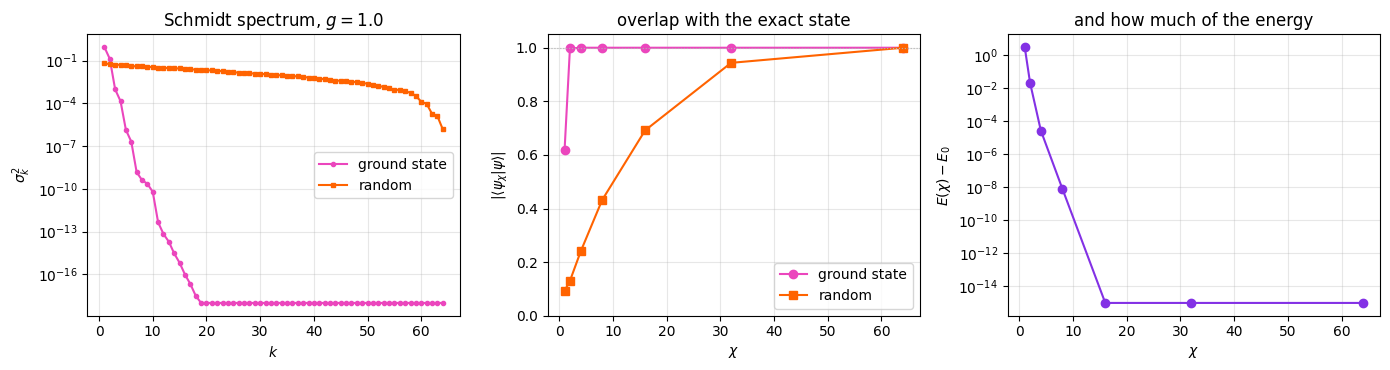

In [109]:
_ = run()

**What to read off.**

* **The spectrum decides.** The ground state has two dominant weights and then a cliff; the random
  state is flat and needs every one of its $2^{L/2}$ values — its entropy is close to the maximum.
  A randomly chosen vector in Hilbert space is incompressible by *any* method.
* **A handful of Schmidt states is enough** for the critical chain, out of maximum of 64.
* **Both columns are second order in the state error.** With $\delta=\lVert|\psi_\chi\rangle-|\psi\rangle\rVert$,
  the overlap column *is* $\delta^2$ ($\delta=3\cdot10^{-5}$ at $\chi=8$), and
  $E-E_0=\sum_{n>0}|c_n|^2(E_n-E_0)$ is $\delta^2$ times the mean excitation energy of what we threw
  away --- which is all their ratio (4 to 9, rising with $\chi$) measures.
* **The energy is still the weaker test,** because that weighting makes it blind to error in
  near-degenerate directions. At $g=0.2$ the two lowest states are split by $8\cdot10^{-9}$: an ansatz
  can mix them almost freely, hold the energy to $10^{-8}$, and be the wrong state. The overlap cannot
  be fooled that way --- worth remembering when the energy is all you have.

## The point: how does the cost grow with the chain?

One $L$ tells you nothing. Fix an accuracy, ask for the smallest $\chi$ that reaches it, and watch
what happens as the chain gets longer --- at the critical point and away from it.

smallest chi with discarded weight < 1e-06, and the entropy, at the middle bond
   (for reference, the largest chi that bond could need: L=8: 16, L=10: 32, L=12: 64, L=14: 128, L=16: 256, L=18: 512)
   L  |    g = 0.5    |    g = 1.0    |    g = 2.0   
   8  |   4  (S=0.689) |   4  (S=0.357) |   3  (S=0.089)
  10  |   4  (S=0.694) |   4  (S=0.379) |   3  (S=0.089)
  12  |   4  (S=0.696) |   5  (S=0.397) |   3  (S=0.089)
  14  |   4  (S=0.696) |   5  (S=0.411) |   3  (S=0.089)
  16  |   4  (S=0.696) |   5  (S=0.423) |   3  (S=0.089)
  18  |   4  (S=0.696) |   6  (S=0.434) |   3  (S=0.089)


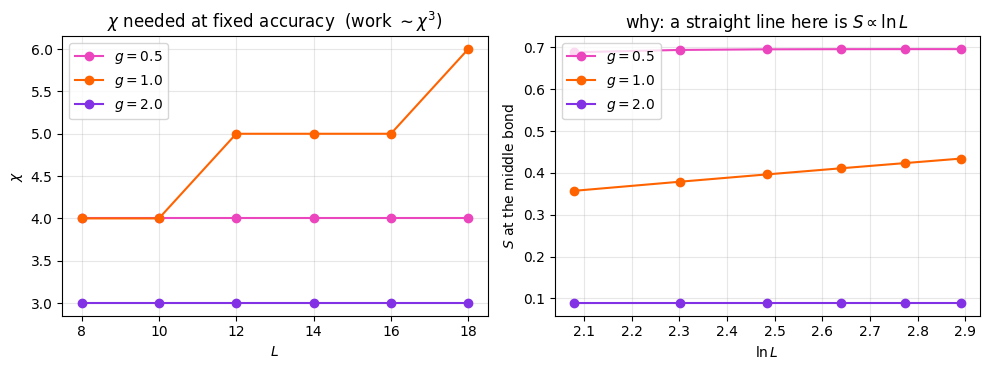

In [110]:
def chi_needed(L, g, tol=1e-6):
    H = ising_H(L, g)
    w, V = spl.eigsh(H, k=1, which='SA')
    psi = V[:, 0] / np.linalg.norm(V[:, 0])
    wt = weights(psi, L)
    tail = np.cumsum(wt[::-1])[::-1]              # discarded weight if we keep k values
    return int(np.sum(tail > tol)), entropy(wt)

def scaling(Ls=(8, 10, 12, 14, 16, 18), gs=(0.5, 1.0, 2.0), tol=1e-6):
    res = {g: [chi_needed(L, g, tol) for L in Ls] for g in gs}
    print(f"smallest chi with discarded weight < {tol:.0e}, and the entropy, at the middle bond")
    print("   (for reference, the largest chi that bond could need: "
          + ", ".join(f"L={L}: {2**(L//2)}" for L in Ls) + ")")
    print("   L  | " + " | ".join(f"   g = {g}   " for g in gs))
    for i, L in enumerate(Ls):
        print(f" {L:3d}  | " + " | ".join(f" {res[g][i][0]:2d}  (S={res[g][i][1]:.3f})" for g in gs))
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
    for g in gs:
        ax[0].plot(Ls, [r[0] for r in res[g]], 'o-', label=f'$g={g}$')
        ax[1].plot(np.log(Ls), [r[1] for r in res[g]], 'o-', label=f'$g={g}$')
    ax[0].set_xlabel('$L$'); ax[0].set_ylabel(r'$\chi$')
    ax[0].set_title(r'$\chi$ needed at fixed accuracy  (work $\sim\chi^3$)')
    ax[1].set_xlabel(r'$\ln L$'); ax[1].set_ylabel('$S$ at the middle bond')
    ax[1].set_title(r'why: a straight line here is $S\propto\ln L$')
    for a in ax: a.legend(); a.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    return res

_ = scaling()

**This is the area law and its violation, measured.**

* Away from the critical point ($g=0.5$ and $g=2$) both columns **saturate**: $\chi$ never moves at
  all (4 and 3), and the entropy climbs only while the chain is still shorter than the correlation
  length, then stops dead --- 0.696 from $L=12$ on at $g=0.5$, and 0.089 from the start at $g=2$,
  where $\xi$ is shorter. A gapped phase becomes genuinely $L$-independent: beyond a few $\xi$, a
  fixed $\chi$ buys a fixed accuracy at any size.
* At $g=1$ both **creep upwards**: $S$ grows like $\tfrac{c}{6}\ln L$ and $\chi$ follows. That is the
  logarithmic violation of the area law, and it is the reason critical chains are the expensive case.
* But look at the size of the effect: $\chi$ goes from 4 to 5 over $L=8\dots16$, and reaches 6 at
  $L=18$. The growth is slow enough that the method still works at
  criticality --- *slowly growing* is not *exponential*.
* The left panel plots $\chi$, not the running time. A sweep costs $\mathcal O(L\chi^3d^2D)$, so the
  work grows as $\chi^3$: the step from $\chi=4$ to $6$ is a factor $(6/4)^3\approx3.4$, not $1.5$.
  Even so, a factor of three for a chain more than twice as long is a bargain compared with the
  $2^L$ of exact diagonalisation.

### Things to try
```python
run(g=0.2)                      # the ordered phase: the spectrum falls off a cliff after two values
run(g=3.0)                      # the paramagnet: nearly a product state, chi = 2 almost suffices
scaling(tol=1e-9)               # a stricter accuracy: every column shifts up, the pattern does not
scaling(Ls=(4, 8, 12, 16))      # fewer points, same picture, and faster
run(L=14, seed=7)               # a different random vector: its curve barely moves
```

L = 12, g = 0.2,  Hilbert space 4096,  largest possible chi at the middle bond = 64
  E0 = -11.1404045838
  entropy at the middle bond:  ground state 0.6932   random 3.6561   (maximum ln 64 = 4.1589)

 chi |  ground state: overlap   1-|<.>|^2      E-E0   |  random: overlap   1-|<.>|^2
   1 |          0.12025752    9.86e-01   5.05e+00  |      0.09314804    9.91e-01
   2 |          0.99997172    5.66e-05   2.25e-04  |      0.13004039    9.83e-01
   4 |          1.00000000    2.75e-10   1.10e-09  |      0.23968354    9.43e-01
   8 |          1.00000000    1.11e-15   -1.42e-14  |      0.43182391    8.14e-01
  16 |          1.00000000    0.00e+00   -1.42e-14  |      0.69166147    5.22e-01
  32 |          1.00000000    2.22e-16   -1.42e-14  |      0.94362555    1.10e-01
  64 |          1.00000000    2.22e-16   -1.42e-14  |      1.00000000    0.00e+00


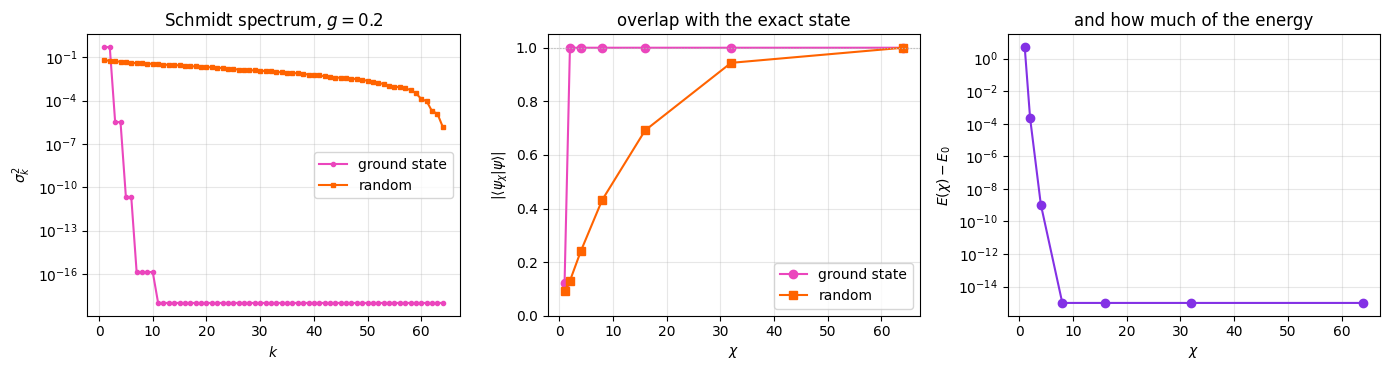

In [111]:
_=run(g=0.2)

L = 12, g = 3.0,  Hilbert space 4096,  largest possible chi at the middle bond = 64
  E0 = -36.9219911304
  entropy at the middle bond:  ground state 0.0432   random 3.6561   (maximum ln 64 = 4.1589)

 chi |  ground state: overlap   1-|<.>|^2      E-E0   |  random: overlap   1-|<.>|^2
   1 |          0.96149531    7.55e-02   9.22e-01  |      0.09314804    9.91e-01
   2 |          0.99999833    3.34e-06   3.94e-05  |      0.13004039    9.83e-01
   4 |          1.00000000    1.29e-10   1.54e-09  |      0.23968354    9.43e-01
   8 |          1.00000000    -4.44e-16   -7.11e-15  |      0.43182391    8.14e-01
  16 |          1.00000000    -4.44e-16   -7.11e-15  |      0.69166147    5.22e-01
  32 |          1.00000000    0.00e+00   0.00e+00  |      0.94362555    1.10e-01
  64 |          1.00000000    0.00e+00   0.00e+00  |      1.00000000    0.00e+00


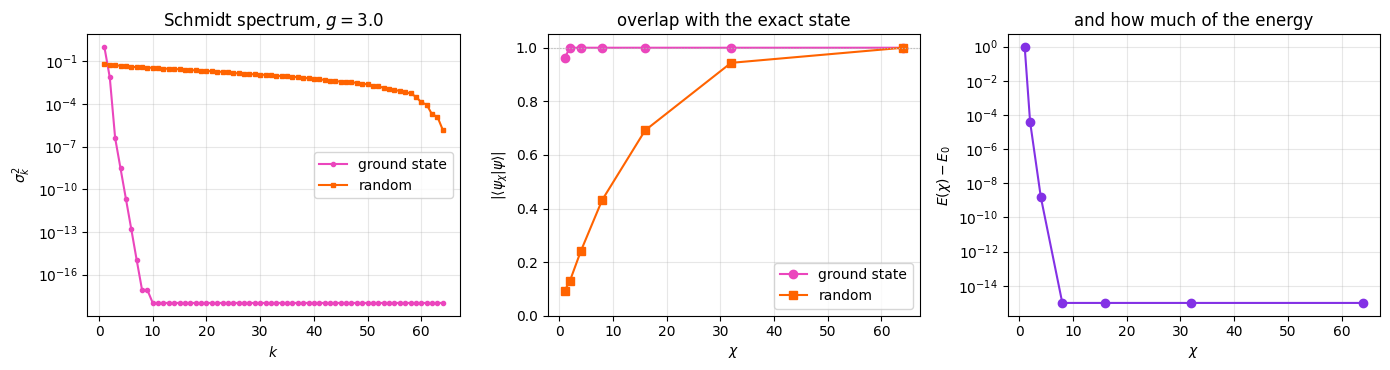

In [112]:
_=run(g=3.0)